# Biznesowa Optymalizacja Modelu: "Gałka" Thresholdingu

In [1]:
# Stałe kosztowe
FP_COST = 10 
FN_COST = 50

In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# 1. FUNKCJA KOSZTU BIZNESOWEGO
def calculate_business_cost(y_true, y_probs, threshold, fp_cost, fn_cost):
    """
    Oblicza koszty biznesowe na podstawie progu odcięcia (threshold).
    """
    y_pred = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    total_cost = (fp * fp_cost) + (fn * fn_cost)
    
    print(f"--- Wyniki dla progu: {threshold:.2f} ---")
    print(f"Błędne alarmy (FP - niepotrzebny voucher): {fp} | Strata: {fp * fp_cost} PLN")
    print(f"Pominięte zwroty (FN - koszty logistyki): {fn} | Strata: {fn * fn_cost} PLN")
    print(f"ŁĄCZNY KOSZT BIZNESOWY: {total_cost} PLN")
    return total_cost


## Symulacja


In [7]:
np.random.seed(42)
n_samples = 1000

# Symulujemy y_true: 10% to zwroty (klasa 1), 90% to brak zwrotu (klasa 0)
y_true = np.random.choice([0, 1], p=[0.9, 0.1], size=n_samples)

# Symulujemy y_probs: prawdopodobieństwa z modelu
# Dla klasy 0 model losuje niższe wartości, dla klasy 1 nieco wyższe
y_probs = np.zeros(n_samples)
y_probs[y_true == 0] = np.random.beta(2, 8, size=sum(y_true == 0)) # Większość blisko 0.2
y_probs[y_true == 1] = np.random.beta(5, 5, size=sum(y_true == 1)) # Większość blisko 0.5

# Testowanie scenariuszy

In [9]:
print("PORÓWNANIE KOSZTÓW DLA RÓŻNYCH PROGÓW (N=1000 zamówień)\n")

thresholds = [0.2, 0.3, 0.5, 0.7]
results = []

for t in thresholds:
    cost = calculate_business_cost(y_true, y_probs, threshold=t, fp_cost=FP_COST, fn_cost=FN_COST)
    results.append(cost)

best_threshold = thresholds[np.argmin(results)]
print(f"\n💡 NAJLEPSZY BIZNESOWO PRÓG: {best_threshold} (Najniższy łączny koszt)")

PORÓWNANIE KOSZTÓW DLA RÓŻNYCH PROGÓW (N=1000 zamówień)

--- Wyniki dla progu: 0.20 ---
Błędne alarmy (FP - niepotrzebny voucher): 417 | Strata: 4170 PLN
Pominięte zwroty (FN - koszty logistyki): 2 | Strata: 100 PLN
ŁĄCZNY KOSZT BIZNESOWY: 4270 PLN
--- Wyniki dla progu: 0.30 ---
Błędne alarmy (FP - niepotrzebny voucher): 196 | Strata: 1960 PLN
Pominięte zwroty (FN - koszty logistyki): 8 | Strata: 400 PLN
ŁĄCZNY KOSZT BIZNESOWY: 2360 PLN
--- Wyniki dla progu: 0.50 ---
Błędne alarmy (FP - niepotrzebny voucher): 11 | Strata: 110 PLN
Pominięte zwroty (FN - koszty logistyki): 49 | Strata: 2450 PLN
ŁĄCZNY KOSZT BIZNESOWY: 2560 PLN
--- Wyniki dla progu: 0.70 ---
Błędne alarmy (FP - niepotrzebny voucher): 0 | Strata: 0 PLN
Pominięte zwroty (FN - koszty logistyki): 86 | Strata: 4300 PLN
ŁĄCZNY KOSZT BIZNESOWY: 4300 PLN

💡 NAJLEPSZY BIZNESOWO PRÓG: 0.3 (Najniższy łączny koszt)


# Wykres 

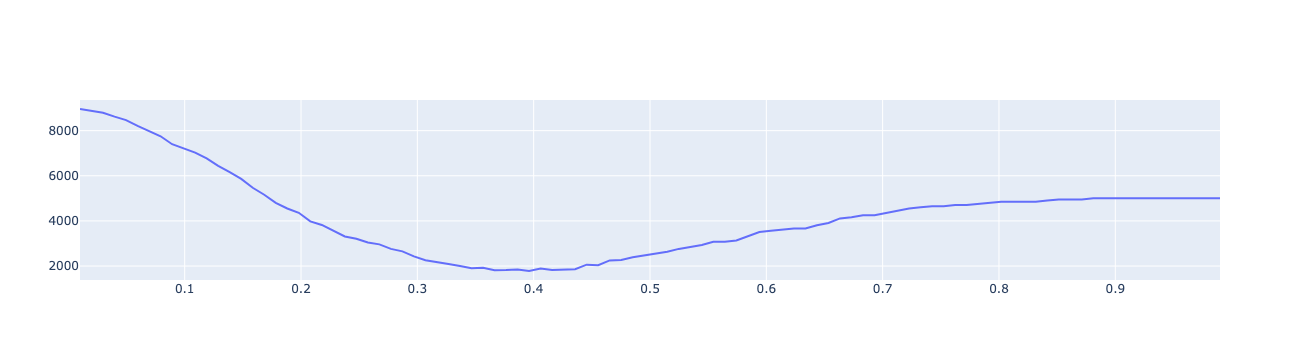

In [11]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Przygotowanie szerszego zakresu progów do wykresu
thresholds = np.linspace(0.01, 0.99, 100)
costs = []
fp_counts = []
fn_counts = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    total_cost = (fp * FP_COST) + (fn * FN_COST)
    costs.append(total_cost)
    fp_counts.append(fp)
    fn_counts.append(fn)

# 2. Tworzenie interaktywnego wykresu w Plotly
fig = go.Figure()

# Linia kosztu całkowitego
fig.add_trace(go.Scatter(
    x=thresholds, y=costs,
    mode='lines',
    name='Łączny Koszt (PLN)'
))



fig.show()

## Zadanie
Zrób symulację dla innych kosztów i inne proporcji zwrotów